In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.preprocessing.dataset_loader import (
    build_dataset_index
)

from src.preprocessing.splitter import (
    create_stratified_split
)

from src.preprocessing.dataset_loader import (
    ChestXRayDataset
)

from src.preprocessing.dataloaders import (
    create_datasets,
    create_dataloaders
)

from src.preprocessing.transforms import (
    train_transform,
    val_transform
)

from src.federated.client import (
    FederatedClient
)

from src.federated.partition import (
    create_client_partitions
)

from src.federated.server import (
    FederatedServer
)

from src.federated.trainer import (
    federated_training
)

In [3]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [4]:
train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

test_paths, test_labels = build_dataset_index(
    "../data/raw/test"
)

In [5]:
(
    X_train,
    X_val,
    y_train,
    y_val
) = create_stratified_split(
    train_paths,
    train_labels
)

In [6]:
(
    train_dataset,
    val_dataset,
    test_dataset
) = create_datasets(
    X_train,
    y_train,
    X_val,
    y_val,
    test_paths,
    test_labels
)

In [7]:
(
    train_loader,
    val_loader,
    test_loader
) = create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=32
)

In [8]:
val_dataset = ChestXRayDataset(
    image_paths=X_val,
    labels=y_val,
    transform=val_transform
)

In [9]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [10]:
client1 = FederatedClient(
    client_id="client_1",
    train_loader=train_loader,
    device=device
)

client2 = FederatedClient(
    client_id="client_2",
    train_loader=train_loader,
    device=device
)

client3 = FederatedClient(
    client_id="client_3",
    train_loader=train_loader,
    device=device
)

client4 = FederatedClient(
    client_id="client_4",
    train_loader=train_loader,
    device=device
)

client5 = FederatedClient(
    client_id="client_5",
    train_loader=train_loader,
    device=device
)

clients = [
    client1,
    client2,
    client3,
    client4,
    client5
]

In [11]:
clients_data = create_client_partitions(
    X_train,
    y_train,
    num_clients=5
)

In [12]:
client_datasets = {}

for client_id, data in clients_data.items():

    dataset = ChestXRayDataset(

        image_paths=data["paths"],

        labels=data["labels"],

        transform=train_transform

    )

    client_datasets[client_id] = dataset 

In [13]:
client_loaders = {}

for client_id, dataset in client_datasets.items():

    loader = DataLoader(

        dataset,

        batch_size=32,

        shuffle=True

    )

    client_loaders[client_id] = loader

In [14]:
for client_id, loader in client_loaders.items():

    print(
        client_id,
        len(loader.dataset)
    )

client_1 835
client_2 835
client_3 834
client_4 834
client_5 834


In [15]:
clients = []

for client_id, loader in client_loaders.items():

    client = FederatedClient(

        client_id=client_id,

        train_loader=loader,

        device=device

    )

    clients.append(
        client
    )

In [16]:
for client in clients:

    print(
        client.client_id,
        len(client.train_loader.dataset)
    )

client_1 835
client_2 835
client_3 834
client_4 834
client_5 834


In [17]:
server = FederatedServer(
    device=device
)

In [18]:
criterion = nn.CrossEntropyLoss()

In [19]:
history = federated_training(

    server=server,

    clients=clients,

    val_loader=val_loader,

    criterion=criterion,

    device=device,

    rounds=15,

    local_epochs=5

)


========== Round 1/15 ==========
0.005696335807442665 0.9926173090934753
0.05881773680448532 0.6737622022628784
0.03705642372369766 0.9727182984352112
0.018552379682660103 0.6997019648551941
0.025259559974074364 0.9757718443870544
0.03154407814145088 0.671584963798523
0.009180108085274696 0.9908279180526733
0.017143109813332558 0.821257472038269
0.007122810930013657 0.9927545189857483
0.009825369343161583 0.8003889322280884
0.021793285384774208 0.9775780439376831
0.04024158790707588 0.7263250350952148
0.0075766537338495255 0.9919518232345581
0.02104055881500244 0.7214996218681335
0.0034387591294944286 0.9962375164031982
0.019229549914598465 0.8292978405952454
0.0039345682598650455 0.9957051873207092
0.023042282089591026 0.8279141783714294
0.006228938233107328 0.9933072924613953
0.03690148890018463 0.8578660488128662
0.0034850765950977802 0.9962040781974792
0.025044288486242294 0.8934049606323242
0.0013745911419391632 0.9984949827194214
0.02000574581325054 0.9390650391578674
0.00098170

In [20]:
print("\nTraining Finished\n")

print(history)


Training Finished

{'train_loss': [0.37357501060874376, 0.3017911329230777, 0.25920046455330314, 0.23366895187784126, 0.21922931503090592, 0.1865709816360915, 0.1663829507706342, 0.16539133448981577, 0.1457757972953496, 0.14703580210882206, 0.14816127974953916, 0.14459165785875586, 0.14387631546430013, 0.14852838322589243, 0.14785467556367315], 'train_acc': [0.8268827160493826, 0.8722376543209878, 0.8927932098765432, 0.9044907407407408, 0.9093518518518519, 0.9265586419753087, 0.9330401234567901, 0.937577160493827, 0.9442746913580248, 0.9459876543209876, 0.9432870370370372, 0.9460493827160492, 0.9466358024691358, 0.9450462962962962, 0.9437345679012346], 'val_loss': [2.640751726699598, 1.6240673299991724, 0.8528912681521792, 1.2805009971965442, 0.3662657037828908, 0.17245072775492162, 0.14204889208529936, 0.13232190382074227, 0.12734477724315543, 0.12550681112616352, 0.12421711551194842, 0.12413946810093793, 0.12393819653626645, 0.1232843825762922, 0.12373987066023277], 'val_acc': [0.74

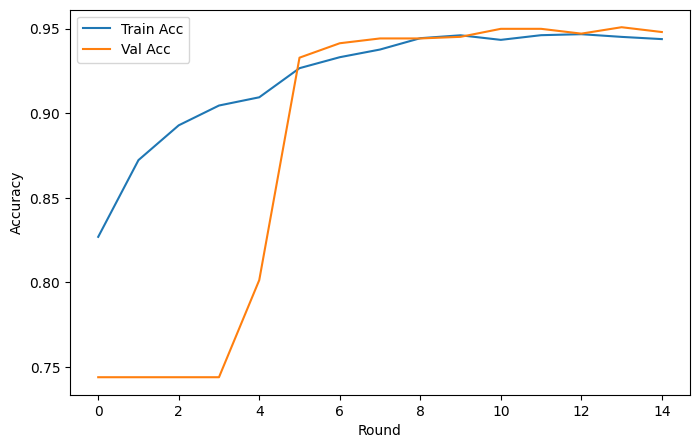

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")

plt.xlabel("Round")
plt.ylabel("Accuracy")

plt.legend()

plt.show()